In [1]:
import numpy as np
import scanpy as sc
from SparseAEH import Kernel
from sklearn.metrics.pairwise import laplacian_kernel,rbf_kernel
from SparseAEH import GaussianNLL

In [2]:
adata_impt_all = sc.read_h5ad('/grp01/sbms_yhhuang/lingyu/STFoundation/Data/NPC/patient1_adata_all_pvalue.h5ad')
spatialxy = np.column_stack((np.array(adata_impt_all.obs['x']), np.array(adata_impt_all.obs['y'])))
adata_impt_all.obsm['spatial'] = spatialxy

In [3]:
true_cov = laplacian_kernel(spatialxy,gamma=0.001)
true_cov

array([[1.00000000e+00, 6.87289279e-01, 4.72839156e-01, ...,
        6.06382247e-04, 4.18012175e-04, 3.47064471e-04],
       [6.87289279e-01, 1.00000000e+00, 6.87976912e-01, ...,
        8.80518165e-04, 6.06988933e-04, 5.03966883e-04],
       [4.72839156e-01, 6.87976912e-01, 1.00000000e+00, ...,
        1.27730869e-03, 8.80518165e-04, 7.31070982e-04],
       ...,
       [6.06382247e-04, 8.80518165e-04, 1.27730869e-03, ...,
        1.00000000e+00, 6.87976912e-01, 5.70638140e-01],
       [4.18012175e-04, 6.06988933e-04, 8.80518165e-04, ...,
        6.87976912e-01, 1.00000000e+00, 8.29443736e-01],
       [3.47064471e-04, 5.03966883e-04, 7.31070982e-04, ...,
        5.70638140e-01, 8.29443736e-01, 1.00000000e+00]])

In [4]:
#gaussian = MixedGaussian(adata_impt_all.obsm['spatial'],group_size=16,cov=true_cov,d=10,l=1e-5)
#gaussian = MixedGaussian(spatial,ss_loc=ss_loc,dependency=dependency,l=0.001)
kernel = Kernel(spatialxy,group_size=32,cov=true_cov)

In [5]:
from scipy.stats import multivariate_normal

In [6]:
n = true_cov.shape[0]
rv = multivariate_normal.rvs(np.zeros(n),0.1*(true_cov+np.eye(n)),100)

In [7]:
rv.shape

(100, 5039)

In [8]:
scipy_ll = multivariate_normal.logpdf(rv,np.zeros(n),0.1*(true_cov+np.eye(n)))

In [ ]:
gaussian.K = 1
gaussian.G = rv.shape[0]
gaussian.N = rv.shape[1]
est_ll = gaussian.compute_ll(Y=rv.T,mean=np.zeros((n,1)),sigma_sq=np.array([[0.1]]),delta=np.array([[1]]))

TypeError: compute_ll() got an unexpected keyword argument 'Y'

In [9]:
est_ll = GaussianNLL(rv.T,kernel,mean=np.zeros((n,1)),sigma_sq=np.array([[0.1]]),delta=np.array([[1]]))

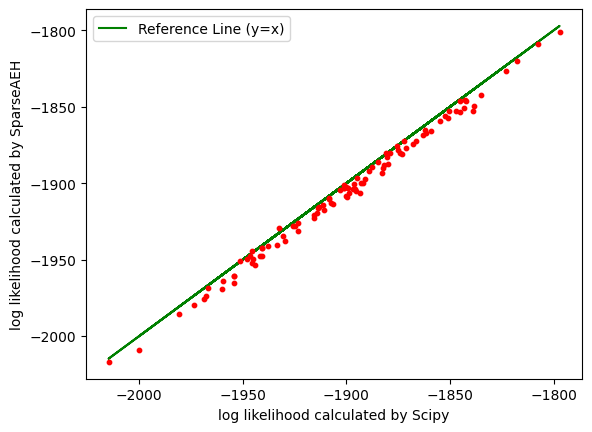

In [10]:
import matplotlib.pyplot as plt
plt.plot(scipy_ll,scipy_ll,c='green',zorder=1,label='Reference Line (y=x)')
#plt.scatter(scipy_ll,est_ll,s=15,c='none',marker='o',edgecolors='red',zorder=2)
plt.scatter(scipy_ll,est_ll,s=10,c='red',marker='o',zorder=2)
plt.xlabel('log likelihood calculated by Scipy')
plt.ylabel('log likelihood calculated by SparseAEH')
plt.legend()
plt.savefig('acc.pdf')

In [10]:
import time
t_1 = []
t_2 = []
t_3 = []
for i in range(10,n,50):
    rv_0 = rv[:,:i]
    true_cov_0 = true_cov[:i,:i]
    
    start = time.time()
    kernel = Kernel(adata_impt_all.obsm['spatial'][:i,:],group_size=16,cov=true_cov)
    est_ll = GaussianNLL(rv_0.T,kernel,mean=np.zeros((i,1)),sigma_sq=np.array([[0.1]]),delta=np.array([[1]]))
    
    #gaussian = MixedGaussian(adata_impt_all.obsm['spatial'][:i,:],group_size=16,cov=true_cov_0,d=10,l=1e-5)
    end = time.time()
    t_3.append(end-start)

    # start = time.time()
    # est_ll = gaussian.compute_ll(Y=rv_0.T,mean=np.zeros((i,1)),sigma_sq=np.array([[0.1]]),delta=np.array([[1]]))
    # end = time.time()
    # t_1.append(end-start)
    
    start = time.time()
    cov_0 = 0.1*(true_cov_0+np.eye(i))
    scipy_ll = multivariate_normal.logpdf(rv_0,np.zeros(i),cov_0)
    end = time.time()
    t_2.append(end-start)


# start = time.time()
# print("hello")
# end = time.time()
# print(end - start)

In [20]:
t_4 = [0]*101
for i in range(101):
    t_4[i] = t_1[i] + t_3[i]


In [12]:
import pandas as pd
dict = { 't2':t_2, 't3':t_3}
time = pd.DataFrame(dict)
time

,t2,t3
0,0.001156,0.009602
1,0.003214,0.009374
2,0.088453,0.093600
3,0.079786,0.084203
4,0.087942,0.104678
...,...,...
96,16.353876,0.570708
97,16.686554,0.580839
98,17.195315,0.597222
99,17.645007,0.612303


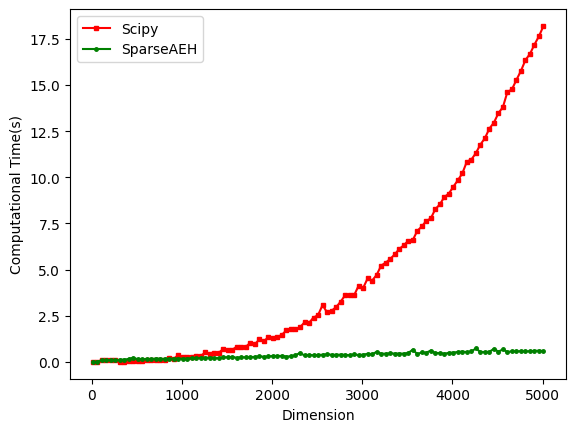

In [ ]:
import matplotlib.pyplot as plt
x = np.arange(10,5039,50)
plt.plot(x,t_2,'s-',color='r',markersize=2.5,label='Scipy')
plt.plot(x,t_3,'o-',color='g',markersize=2.5,label='SparseAEH')
plt.legend()
plt.xlabel('Dimension')
plt.ylabel('Computational Time(s)')
plt.savefig('time.pdf')

In [17]:
from typing import Optional
import math

def generate_spatial_coords(amount: int, jitter: float = 0.5, seed: Optional[int] = None):
    if amount <= 0:
        raise ValueError("amount must be > 0")
    if jitter <= 0:
        raise ValueError("jitter must be > 0")

    rng = np.random.default_rng(seed)
    r = int(round(math.sqrt(amount)))

    xs = np.arange(-r, r + 1)
    ys = np.arange(-r, r + 1)
    grid = np.array([(x, y) for x in xs for y in ys], dtype=float)

    noise = rng.uniform(-jitter, jitter, size=grid.shape)
    coords = grid + noise
    return coords

In [20]:
coord = generate_spatial_coords(10000,0.3,42)

In [21]:
true_cov = laplacian_kernel(coord,gamma=0.001)
true_cov

array([[1.        , 0.99879485, 0.99727381, ..., 0.67168172, 0.67116401,
        0.67019888],
       [0.99879485, 1.        , 0.99837572, ..., 0.67249217, 0.67197384,
        0.67100754],
       [0.99727381, 0.99837572, 1.        , ..., 0.67296867, 0.67244997,
        0.67148299],
       ...,
       [0.67168172, 0.67249217, 0.67296867, ..., 1.        , 0.99877928,
        0.99779235],
       [0.67116401, 0.67197384, 0.67244997, ..., 0.99877928, 1.        ,
        0.998562  ],
       [0.67019888, 0.67100754, 0.67148299, ..., 0.99779235, 0.998562  ,
        1.        ]])

In [22]:
kernel = Kernel(coord,group_size=32,cov=true_cov)

In [23]:
n = true_cov.shape[0]
rv = multivariate_normal.rvs(np.zeros(n),0.1*(true_cov+np.eye(n)),100)

: 